Introduction
This final project extends my midterm analysis of e-commerce product data by incorporating cart-level data from the same API and using both Python and SQL. The target audience is an e-commerce category manager, merchandising analyst, or growth analyst who wants to understand not only how products differ in terms of price, discounting, ratings, and inventory, but also how those product characteristics relate to cart behavior and cart value.
The main goal of this analysis is to identify which types of products are associated with larger cart totals, larger discounted cart totals, and higher quantities in carts. To answer this, I combine product-level and cart-level datasets, perform exploratory analysis in both Python and SQL, engineer additional features, and estimate regression models.


In [1]:
!pip install requests pandas seaborn matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
url = "https://dummyjson.com/products?limit=0"

response = requests.get(url)
data = response.json()

print(data.keys())
print("Number of products:", len(data["products"]))

dict_keys(['products', 'total', 'skip', 'limit'])
Number of products: 194


In [4]:
carts_url = "https://dummyjson.com/carts?limit=0"
carts_response = requests.get(carts_url)
carts_data = carts_response.json()

print(carts_data.keys())
print("Number of carts:", len(carts_data["carts"]))

dict_keys(['carts', 'total', 'skip', 'limit'])
Number of carts: 50


In [28]:
carts = carts_data["carts"]

print(type(carts))
print(carts[0])

<class 'list'>
{'id': 1, 'products': [{'id': 168, 'title': 'Charger SXT RWD', 'price': 32999.99, 'quantity': 3, 'total': 98999.97, 'discountPercentage': 13.39, 'discountedTotal': 85743.87, 'thumbnail': 'https://cdn.dummyjson.com/products/images/vehicle/Charger%20SXT%20RWD/thumbnail.png'}, {'id': 78, 'title': 'Apple MacBook Pro 14 Inch Space Grey', 'price': 1999.99, 'quantity': 2, 'total': 3999.98, 'discountPercentage': 18.52, 'discountedTotal': 3259.18, 'thumbnail': 'https://cdn.dummyjson.com/products/images/laptops/Apple%20MacBook%20Pro%2014%20Inch%20Space%20Grey/thumbnail.png'}, {'id': 183, 'title': 'Green Oval Earring', 'price': 24.99, 'quantity': 5, 'total': 124.94999999999999, 'discountPercentage': 6.28, 'discountedTotal': 117.1, 'thumbnail': 'https://cdn.dummyjson.com/products/images/womens-jewellery/Green%20Oval%20Earring/thumbnail.png'}, {'id': 100, 'title': 'Apple Airpods', 'price': 129.99, 'quantity': 5, 'total': 649.95, 'discountPercentage': 12.84, 'discountedTotal': 566.5, 

In [29]:
cart_rows = []

for cart in carts:
    cart_id = cart["id"]
    user_id = cart["userId"]
    cart_total = cart["total"]
    cart_discounted_total = cart["discountedTotal"]
    total_products = cart["totalProducts"]
    total_quantity = cart["totalQuantity"]

    for item in cart["products"]:
        cart_rows.append({
            "cart_id": cart_id,
            "user_id": user_id,
            "product_id": item["id"],
            "cart_item_quantity": item["quantity"],
            "cart_item_total": item["total"],
            "cart_item_discounted_total": item["discountedTotal"],
            "cart_total": cart_total,
            "cart_discounted_total": cart_discounted_total,
            "total_products_in_cart": total_products,
            "total_quantity_in_cart": total_quantity
        })

carts_df = pd.DataFrame(cart_rows)
carts_df.head()

,cart_id,user_id,product_id,cart_item_quantity,cart_item_total,cart_item_discounted_total,cart_total,cart_discounted_total,total_products_in_cart,total_quantity_in_cart
0,1,33,168,3,98999.97,85743.87,103774.85,89686.65,4,15
1,1,33,78,2,3999.98,3259.18,103774.85,89686.65,4,15
2,1,33,183,5,124.95,117.10,103774.85,89686.65,4,15
3,1,33,100,5,649.95,566.50,103774.85,89686.65,4,15
4,2,142,144,4,179.96,159.32,4794.80,4288.95,5,20


In [30]:
carts_df.info()
carts_df.isnull().sum()
carts_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cart_id                     198 non-null    int64  
 1   user_id                     198 non-null    int64  
 2   product_id                  198 non-null    int64  
 3   cart_item_quantity          198 non-null    int64  
 4   cart_item_total             198 non-null    float64
 5   cart_item_discounted_total  198 non-null    float64
 6   cart_total                  198 non-null    float64
 7   cart_discounted_total       198 non-null    float64
 8   total_products_in_cart      198 non-null    int64  
 9   total_quantity_in_cart      198 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 15.6 KB


,cart_id,user_id,product_id,cart_item_quantity,cart_item_total,cart_item_discounted_total,cart_total,cart_discounted_total,total_products_in_cart,total_quantity_in_cart
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,24.676768,109.737374,95.464646,3.252525,5072.059899,4581.132475,20875.459747,18906.824040,4.464646,14.631313
std,14.523797,61.686383,54.129346,1.350641,21232.520264,19306.729150,39352.486124,35869.297741,1.319999,5.035955
min,1.000000,6.000000,1.000000,1.000000,0.990000,0.800000,36.280000,34.970000,2.000000,2.000000
25%,13.000000,52.000000,46.250000,2.000000,29.982500,25.477500,568.360000,476.760000,4.000000,13.000000
50%,23.500000,108.000000,97.000000,3.000000,94.960000,87.365000,3359.790000,2936.580000,4.000000,14.000000
75%,38.000000,170.000000,140.750000,4.000000,449.970000,432.110000,14779.377500,12235.300000,6.000000,19.000000
max,50.000000,203.000000,193.000000,5.000000,159999.950000,148159.950000,160289.860000,148416.410000,6.000000,23.000000


In [32]:
products_df = df.copy()

products_df = products_df.rename(columns={"id": "product_id"})

products_df.head()

,product_id,title,category,brand,price,discountPercentage,rating,stock,weight,minimumOrderQuantity,discounted_price,value_score,stock_value,high_rating,price_bucket,log_price,discount_amount,is_low_stock
0,1,Essence Mascara Lash Princess,beauty,Essence,9.99,10.48,2.56,99,4,48,8.943048,0.256256,989.01,0,Low,2.396986,1.046952,0
1,2,Eyeshadow Palette with Mirror,beauty,Glamour Beauty,19.99,18.19,2.86,34,9,20,16.353819,0.143072,679.66,0,Low,3.044046,3.636181,0
2,3,Powder Canister,beauty,Velvet Touch,14.99,9.84,4.64,89,8,22,13.514984,0.309540,1334.11,1,Low,2.771964,1.475016,0
3,4,Red Lipstick,beauty,Chic Cosmetics,12.99,12.16,4.36,91,1,40,11.410416,0.335643,1182.09,0,Low,2.638343,1.579584,0
4,5,Red Nail Polish,beauty,Nail Couture,8.99,11.44,4.32,79,8,22,7.961544,0.480534,710.21,0,Low,2.301585,1.028456,0


In [33]:
merged_df = pd.merge(
    carts_df,
    products_df,
    on="product_id",
    how="left"
)

merged_df.head()

,cart_id,user_id,product_id,cart_item_quantity,cart_item_total,cart_item_discounted_total,cart_total,cart_discounted_total,total_products_in_cart,total_quantity_in_cart,...,weight,minimumOrderQuantity,discounted_price,value_score,stock_value,high_rating,price_bucket,log_price,discount_amount,is_low_stock
0,1,33,168,3,98999.97,85743.87,103774.85,89686.65,4,15,...,6,1,30284.090823,0.000078,1880999.43,0,High,10.404293,2715.899177,0
1,1,33,78,2,3999.98,3259.18,103774.85,89686.65,4,15,...,9,1,1906.190469,0.001825,47999.76,0,High,7.601397,93.799531,0
2,1,33,183,5,124.95,117.10,103774.85,89686.65,4,15,...,10,19,21.196518,0.142857,1824.27,0,Low,3.257712,3.793482,0
3,1,33,100,5,649.95,566.50,103774.85,89686.65,4,15,...,4,4,109.789554,0.031926,8709.33,0,High,4.875121,20.200446,0
4,2,142,144,4,179.96,159.32,4794.80,4288.95,5,20,...,10,4,40.652964,0.104245,449.90,1,Medium,3.828424,4.337036,1


In [34]:
print("Merged rows:", len(merged_df))
print("Missing product matches:", merged_df["title"].isnull().sum())

Merged rows: 198
Missing product matches: 0


In [35]:
merged_df.info()
merged_df.isnull().sum().sort_values(ascending=False)
merged_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cart_id                     198 non-null    int64  
 1   user_id                     198 non-null    int64  
 2   product_id                  198 non-null    int64  
 3   cart_item_quantity          198 non-null    int64  
 4   cart_item_total             198 non-null    float64
 5   cart_item_discounted_total  198 non-null    float64
 6   cart_total                  198 non-null    float64
 7   cart_discounted_total       198 non-null    float64
 8   total_products_in_cart      198 non-null    int64  
 9   total_quantity_in_cart      198 non-null    int64  
 10  title                       198 non-null    str    
 11  category                    198 non-null    str    
 12  brand                       99 non-null     str    
 13  price                       198 non-null    fl

,cart_id,user_id,product_id,cart_item_quantity,cart_item_total,cart_item_discounted_total,cart_total,cart_discounted_total,total_products_in_cart,total_quantity_in_cart,...,stock,weight,minimumOrderQuantity,discounted_price,value_score,stock_value,high_rating,log_price,discount_amount,is_low_stock
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,...,198.000000,198.000000,198.000000,198.000000,198.000000,1.980000e+02,198.000000,198.000000,198.000000,198.000000
mean,24.676768,109.737374,95.464646,3.252525,5072.059899,4581.132475,20875.459747,18906.824040,4.464646,14.631313,...,51.368687,5.156566,13.636364,1260.833246,0.412280,8.048386e+04,0.217172,3.971421,135.579986,0.196970
std,14.523797,61.686383,54.129346,1.350641,21232.520264,19306.729150,39352.486124,35869.297741,1.319999,5.035955,...,29.816025,3.036284,14.217994,4778.232920,0.781419,3.026179e+05,0.413366,2.285364,619.006527,0.398717
min,1.000000,6.000000,1.000000,1.000000,0.990000,0.800000,36.280000,34.970000,2.000000,2.000000,...,0.000000,1.000000,1.000000,0.713370,0.000078,0.000000e+00,0.000000,0.582216,0.002064,0.000000
25%,13.000000,52.000000,46.250000,2.000000,29.982500,25.477500,568.360000,476.760000,4.000000,13.000000,...,27.000000,2.250000,3.000000,8.836271,0.028002,2.957925e+02,0.000000,2.325435,0.767781,0.000000
50%,23.500000,108.000000,97.000000,3.000000,94.960000,87.365000,3359.790000,2936.580000,4.000000,14.000000,...,53.000000,5.000000,8.000000,25.530487,0.125313,1.131935e+03,0.000000,3.433665,3.452723,0.000000
75%,38.000000,170.000000,140.750000,4.000000,449.970000,432.110000,14779.377500,12235.300000,6.000000,19.000000,...,77.000000,8.000000,18.000000,139.618192,0.345034,7.104485e+03,0.000000,5.017214,20.200446,0.000000
max,50.000000,203.000000,193.000000,5.000000,159999.950000,148159.950000,160289.860000,148416.410000,6.000000,23.000000,...,100.000000,10.000000,50.000000,30284.090823,5.010101,1.880999e+06,1.000000,10.404293,4723.198524,1.000000


In [36]:
merged_df["cart_share_of_total"] = merged_df["cart_item_discounted_total"] / merged_df["cart_discounted_total"]
merged_df["quantity_price_interaction"] = merged_df["cart_item_quantity"] * merged_df["price"]
merged_df["discount_amount"] = merged_df["price"] - merged_df["discounted_price"]
merged_df["high_cart_value"] = (merged_df["cart_discounted_total"] >= merged_df["cart_discounted_total"].median()).astype(int)
merged_df["high_quantity_item"] = (merged_df["cart_item_quantity"] >= merged_df["cart_item_quantity"].median()).astype(int)
merged_df["log_cart_discounted_total"] = np.log1p(merged_df["cart_discounted_total"])
merged_df["log_price"] = np.log1p(merged_df["price"])

In [37]:
def cart_size_bucket(total_quantity):
    if total_quantity <= 5:
        return "Small"
    elif total_quantity <= 10:
        return "Medium"
    else:
        return "Large"

merged_df["cart_size_bucket"] = merged_df["total_quantity_in_cart"].apply(cart_size_bucket)

In [38]:
merged_df[[
    "cart_id",
    "product_id",
    "price",
    "discounted_price",
    "cart_item_quantity",
    "cart_item_discounted_total",
    "cart_discounted_total",
    "cart_share_of_total",
    "high_cart_value",
    "cart_size_bucket"
]].head()

,cart_id,product_id,price,discounted_price,cart_item_quantity,cart_item_discounted_total,cart_discounted_total,cart_share_of_total,high_cart_value,cart_size_bucket
0,1,168,32999.99,30284.090823,3,85743.87,89686.65,0.956038,1,Large
1,1,78,1999.99,1906.190469,2,3259.18,89686.65,0.036340,1,Large
2,1,183,24.99,21.196518,5,117.10,89686.65,0.001306,1,Large
3,1,100,129.99,109.789554,5,566.50,89686.65,0.006316,1,Large
4,2,144,44.99,40.652964,4,159.32,4288.95,0.037147,1,Large


In [39]:
final_table_1 = merged_df.groupby("category")[[
    "cart_item_quantity",
    "cart_item_discounted_total",
    "rating",
    "price"
]].mean().sort_values("cart_item_discounted_total", ascending=False)

final_table_1

,cart_item_quantity,cart_item_discounted_total,rating,price
category,,,,
vehicle,4.000000,113849.342000,3.498000,31599.990000
womens-watches,3.200000,20658.348000,3.372000,6359.990000
mens-watches,3.250000,16790.860000,3.763750,6096.240000
motorcycle,2.500000,11018.525000,4.425000,5749.990000
furniture,4.500000,5691.925000,4.180000,1349.990000
laptops,3.200000,4453.664000,4.046000,1619.990000
smartphones,3.157895,1262.807368,3.548421,423.674211
tablets,2.000000,1148.260000,4.680000,599.990000
mobile-accessories,3.684211,398.824211,3.782105,117.411053


Categories differ not only in ratings and prices, but also in the average discounted value they contribute inside carts.
This suggests that some categories drive more commercial value per cart item than others.

In [40]:
final_table_2 = merged_df.groupby("brand")[[
    "cart_item_quantity",
    "cart_item_discounted_total",
    "rating"
]].mean().sort_values("cart_item_discounted_total", ascending=False).head(15)

final_table_2

,cart_item_quantity,cart_item_discounted_total,rating
brand,,,
Chrysler,4.25,120875.710000,3.7275
Dodge,3.00,85743.870000,2.5800
Rolex,3.40,38331.768000,3.5000
IWC,3.00,13148.973333,2.9300
SpeedMaster,2.00,12025.480000,3.9400
Generic Motors,3.00,10011.570000,4.9100
Annibale Colombo,5.00,8731.400000,4.7700
Dell,5.00,7207.450000,2.6700
Huawei,3.50,4410.455000,4.9800


Final Table 2: Brand-Level Cart Performance

This table analyzes cart purchasing behavior at the brand level.  
By grouping the merged dataset by brand, we calculate the average cart item quantity, cart spending, product rating, and price for each brand.

This helps identify which brands tend to generate higher spending or larger purchase quantities in shopping carts. The analysis can reveal whether premium brands dominate cart spending or whether mid-priced brands drive higher purchasing volumes.


In [41]:
final_table_3 = merged_df.groupby("cart_size_bucket")[[
    "cart_discounted_total",
    "cart_item_quantity",
    "cart_share_of_total"
]].mean()

final_table_3

,cart_discounted_total,cart_item_quantity,cart_share_of_total
cart_size_bucket,,,
Large,21657.418274,3.339286,0.214286
Medium,4444.440556,3.555556,0.444444
Small,2092.080000,1.583333,0.500000


Final Table 3: Price Bucket Purchase Behavior

This table compares purchasing patterns across different price ranges. Products are grouped into Low, Medium, and High price buckets based on their product price.

The table shows the average cart item quantity, total cart spending, and product ratings for each price bucket. This analysis helps determine whether customers tend to buy larger quantities of lower-priced products or spend more on premium products within their carts.


In [42]:
final_table_4 = merged_df.groupby("price_bucket")[[
    "cart_item_quantity",
    "cart_item_discounted_total",
    "rating"
]].mean()

final_table_4

,cart_item_quantity,cart_item_discounted_total,rating
price_bucket,,,
High,3.157895,15717.897544,3.754211
Low,3.233333,30.182444,3.724778
Medium,3.392157,165.248039,3.951176


Final Table 4: Category-Level Cart Spending

This table aggregates cart-level purchasing behavior by product category. It calculates the average quantity purchased, cart spending, product ratings, and prices within each category.

The goal of this analysis is to identify which product categories generate the highest cart spending and which categories tend to have higher customer ratings. This can help e-commerce analysts understand which categories drive the most revenue in shopping carts.


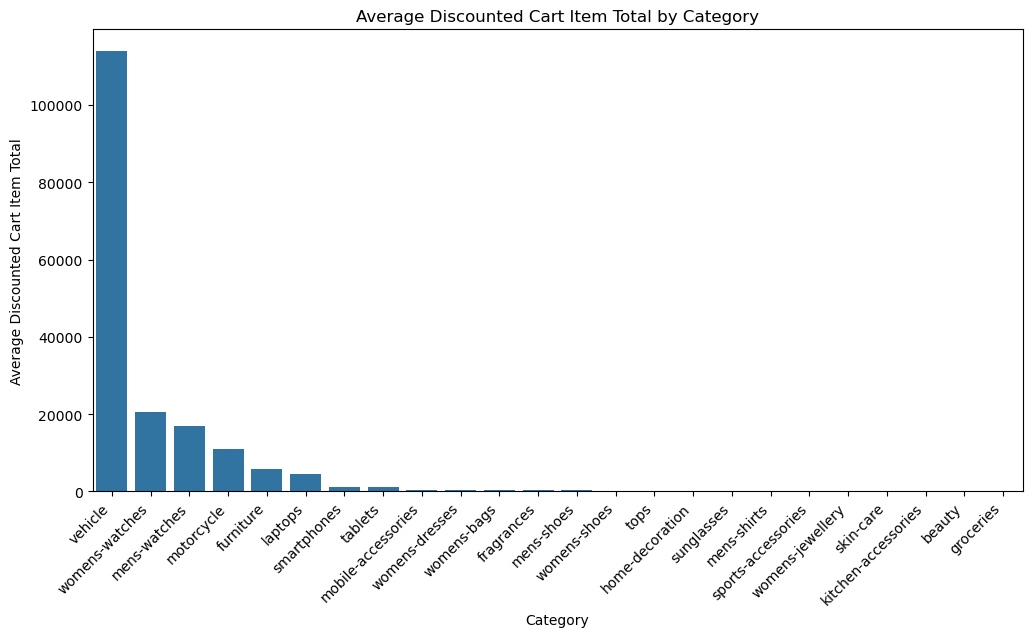

In [43]:
plt.figure(figsize=(12, 6))
category_cart_value = merged_df.groupby("category")["cart_item_discounted_total"].mean().sort_values(ascending=False)

sns.barplot(x=category_cart_value.index, y=category_cart_value.values)
plt.title("Average Discounted Cart Item Total by Category")
plt.xlabel("Category")
plt.ylabel("Average Discounted Cart Item Total")
plt.xticks(rotation=45, ha="right")
plt.show()

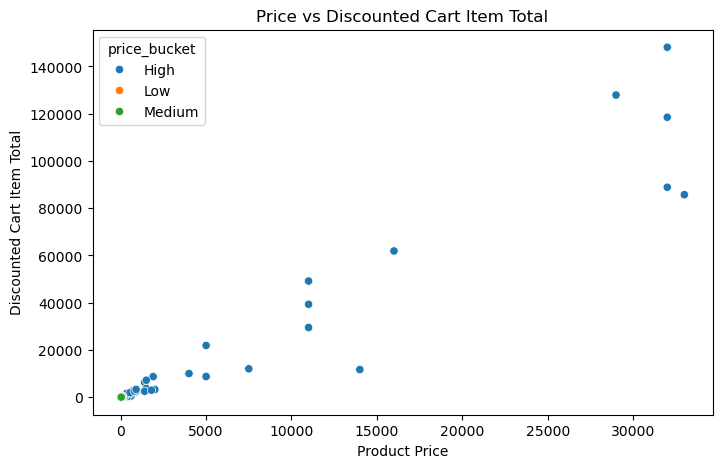

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged_df, x="price", y="cart_item_discounted_total", hue="price_bucket")
plt.title("Price vs Discounted Cart Item Total")
plt.xlabel("Product Price")
plt.ylabel("Discounted Cart Item Total")
plt.show()

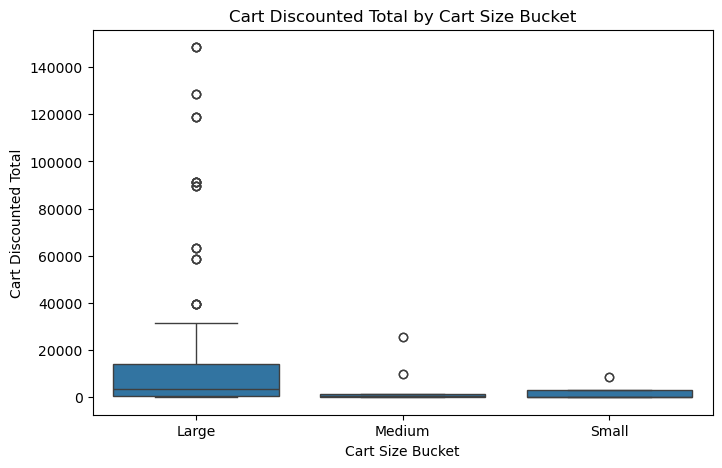

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="cart_size_bucket", y="cart_discounted_total")
plt.title("Cart Discounted Total by Cart Size Bucket")
plt.xlabel("Cart Size Bucket")
plt.ylabel("Cart Discounted Total")
plt.show()

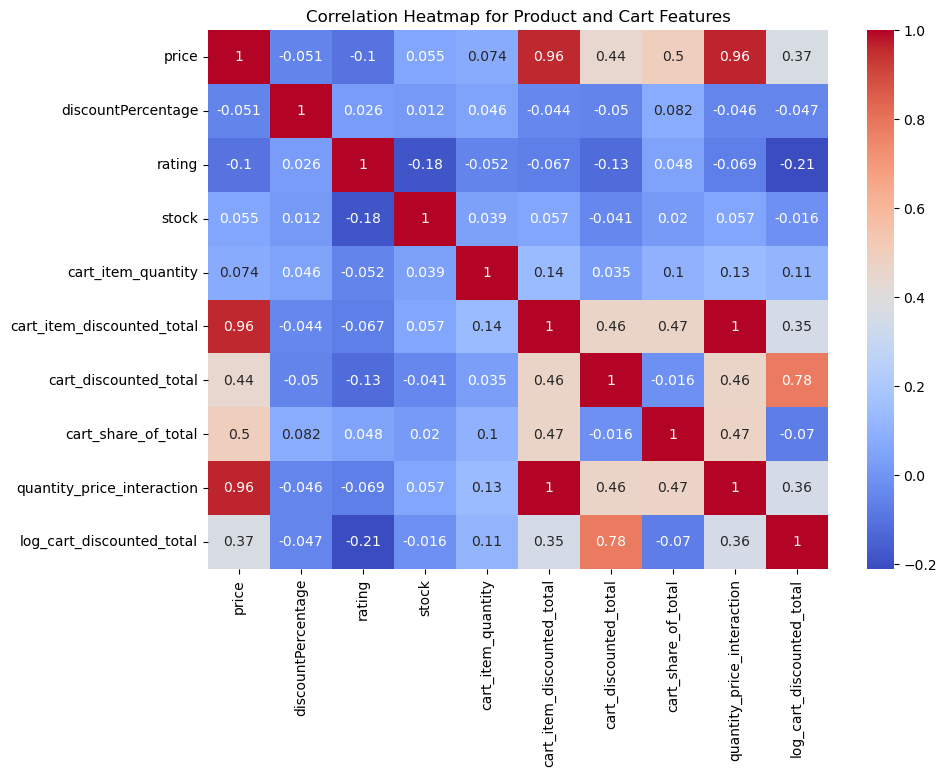

In [46]:
plt.figure(figsize=(10, 7))

final_corr_cols = [
    "price",
    "discountPercentage",
    "rating",
    "stock",
    "cart_item_quantity",
    "cart_item_discounted_total",
    "cart_discounted_total",
    "cart_share_of_total",
    "quantity_price_interaction",
    "log_cart_discounted_total"
]

sns.heatmap(merged_df[final_corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Product and Cart Features")
plt.show()

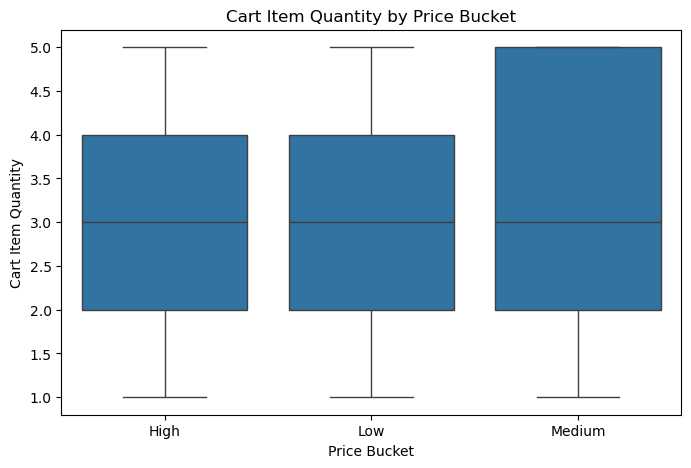

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="price_bucket", y="cart_item_quantity")
plt.title("Cart Item Quantity by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Cart Item Quantity")
plt.show()

In [48]:
import sqlite3

In [49]:
conn = sqlite3.connect("ecommerce_final.db")

In [50]:
products_df.to_sql("products", conn, if_exists="replace", index=False)
carts_df.to_sql("cart_items", conn, if_exists="replace", index=False)

198

In [51]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql_query(query, conn)

,name
0,products
1,cart_items


In [52]:
query1 = """
SELECT
    category,
    AVG(price) AS avg_price,
    AVG(rating) AS avg_rating,
    AVG(stock) AS avg_stock
FROM products
GROUP BY category
ORDER BY avg_price DESC
"""

pd.read_sql_query(query1, conn)

,category,avg_price,avg_rating,avg_stock
0,vehicle,31199.990000,3.394000,68.200000
1,mens-watches,8098.323333,3.660000,58.166667
2,motorcycle,7699.990000,3.666000,36.000000
3,womens-watches,6585.990000,3.476000,31.600000
4,laptops,1559.990000,3.622000,51.600000
5,furniture,1199.990000,4.006000,49.000000
6,tablets,483.323333,3.860000,67.000000
7,smartphones,424.990000,3.698125,43.437500
8,womens-bags,175.990000,3.360000,60.000000
9,mobile-accessories,146.990000,3.851429,37.928571


In [53]:
query2 = """
SELECT
    product_id,
    AVG(cart_item_quantity) AS avg_quantity,
    AVG(cart_item_discounted_total) AS avg_discounted_value
FROM cart_items
GROUP BY product_id
ORDER BY avg_discounted_value DESC
LIMIT 10
"""

pd.read_sql_query(query2, conn)

,product_id,avg_quantity,avg_discounted_value
0,167,5.0,127918.960000
1,171,4.0,118527.960000
2,168,3.0,85743.870000
3,191,4.0,61913.560000
4,97,4.0,39344.763333
5,190,3.0,13148.973333
6,117,2.0,12025.480000
7,98,1.0,11710.990000
8,113,3.0,10011.570000
9,11,5.0,8731.400000


In [54]:
query3 = """
SELECT
    p.category,
    AVG(c.cart_item_quantity) AS avg_quantity,
    AVG(c.cart_item_discounted_total) AS avg_discounted_total
FROM cart_items c
JOIN products p
ON c.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_discounted_total DESC
"""

pd.read_sql_query(query3, conn)

,category,avg_quantity,avg_discounted_total
0,vehicle,4.000000,113849.342000
1,womens-watches,3.200000,20658.348000
2,mens-watches,3.250000,16790.860000
3,motorcycle,2.500000,11018.525000
4,furniture,4.500000,5691.925000
5,laptops,3.200000,4453.664000
6,smartphones,3.157895,1262.807368
7,tablets,2.000000,1148.260000
8,mobile-accessories,3.684211,398.824211
9,womens-dresses,2.750000,324.980000


In [55]:
query4 = """
SELECT
    p.price_bucket,
    AVG(c.cart_item_quantity) AS avg_quantity,
    AVG(c.cart_item_discounted_total) AS avg_discounted_total
FROM cart_items c
JOIN products p
ON c.product_id = p.product_id
GROUP BY p.price_bucket
ORDER BY avg_discounted_total DESC
"""

pd.read_sql_query(query4, conn)

,price_bucket,avg_quantity,avg_discounted_total
0,High,3.157895,15717.897544
1,Medium,3.392157,165.248039
2,Low,3.233333,30.182444


In [56]:
query5 = """
SELECT
    p.brand,
    AVG(c.cart_item_discounted_total) AS avg_cart_value,
    AVG(p.rating) AS avg_rating
FROM cart_items c
JOIN products p
ON c.product_id = p.product_id
GROUP BY p.brand
ORDER BY avg_cart_value DESC
LIMIT 15
"""

pd.read_sql_query(query5, conn)

,brand,avg_cart_value,avg_rating
0,Chrysler,120875.710000,3.7275
1,Dodge,85743.870000,2.5800
2,Rolex,38331.768000,3.5000
3,IWC,13148.973333,2.9300
4,SpeedMaster,12025.480000,3.9400
5,Generic Motors,10011.570000,4.9100
6,Annibale Colombo,8731.400000,4.7700
7,Dell,7207.450000,2.6700
8,Huawei,4410.455000,4.9800
9,Longines,3760.170000,3.8700


In [58]:
model_df = merged_df[[
    "price",
    "discountPercentage",
    "rating",
    "stock",
    "cart_item_quantity",
    "quantity_price_interaction",
    "cart_share_of_total",
    "log_cart_discounted_total"
]]

In [59]:
from sklearn.model_selection import train_test_split

X = model_df.drop("log_cart_discounted_total", axis=1)
y = model_df["log_cart_discounted_total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.02327012181818744
RMSE: 1.992006438895714


In [63]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

coefficients

,feature,coefficient
4,cart_item_quantity,0.211096
0,price,0.000316
5,quantity_price_interaction,-0.000028
1,discountPercentage,-0.003337
3,stock,-0.004217
2,rating,-0.538022
6,cart_share_of_total,-1.981244


In [31]:
df.head()
df.columns

Index(['id', 'title', 'category', 'brand', 'price', 'discountPercentage',
       'rating', 'stock', 'weight', 'minimumOrderQuantity', 'discounted_price',
       'value_score', 'stock_value', 'high_rating', 'price_bucket',
       'log_price', 'discount_amount', 'is_low_stock'],
      dtype='str')

In [5]:
products = data["products"]
df = pd.DataFrame(products)

df.head()

,id,title,description,category,price,discountPercentage,rating,stock,tags,brand,...,dimensions,warrantyInformation,shippingInformation,availabilityStatus,reviews,returnPolicy,minimumOrderQuantity,meta,images,thumbnail
0,1,Essence Mascara Lash Princess,The Essence Mascara Lash Princess is a popular...,beauty,9.99,10.48,2.56,99,"[beauty, mascara]",Essence,...,"{'width': 15.14, 'height': 13.08, 'depth': 22.99}",1 week warranty,Ships in 3-5 business days,In Stock,"[{'rating': 3, 'comment': 'Would not recommend...",No return policy,48,"{'createdAt': '2025-04-30T09:41:02.053Z', 'upd...",[https://cdn.dummyjson.com/product-images/beau...,https://cdn.dummyjson.com/product-images/beaut...
1,2,Eyeshadow Palette with Mirror,The Eyeshadow Palette with Mirror offers a ver...,beauty,19.99,18.19,2.86,34,"[beauty, eyeshadow]",Glamour Beauty,...,"{'width': 9.26, 'height': 22.47, 'depth': 27.67}",1 year warranty,Ships in 2 weeks,In Stock,"[{'rating': 5, 'comment': 'Great product!', 'd...",7 days return policy,20,"{'createdAt': '2025-04-30T09:41:02.053Z', 'upd...",[https://cdn.dummyjson.com/product-images/beau...,https://cdn.dummyjson.com/product-images/beaut...
2,3,Powder Canister,The Powder Canister is a finely milled setting...,beauty,14.99,9.84,4.64,89,"[beauty, face powder]",Velvet Touch,...,"{'width': 29.27, 'height': 27.93, 'depth': 20.59}",3 months warranty,Ships in 1-2 business days,In Stock,"[{'rating': 4, 'comment': 'Would buy again!', ...",No return policy,22,"{'createdAt': '2025-04-30T09:41:02.053Z', 'upd...",[https://cdn.dummyjson.com/product-images/beau...,https://cdn.dummyjson.com/product-images/beaut...
3,4,Red Lipstick,The Red Lipstick is a classic and bold choice ...,beauty,12.99,12.16,4.36,91,"[beauty, lipstick]",Chic Cosmetics,...,"{'width': 18.11, 'height': 28.38, 'depth': 22.17}",3 year warranty,Ships in 1 week,In Stock,"[{'rating': 4, 'comment': 'Great product!', 'd...",7 days return policy,40,"{'createdAt': '2025-04-30T09:41:02.053Z', 'upd...",[https://cdn.dummyjson.com/product-images/beau...,https://cdn.dummyjson.com/product-images/beaut...
4,5,Red Nail Polish,The Red Nail Polish offers a rich and glossy r...,beauty,8.99,11.44,4.32,79,"[beauty, nail polish]",Nail Couture,...,"{'width': 21.63, 'height': 16.48, 'depth': 29.84}",1 month warranty,Ships overnight,In Stock,"[{'rating': 2, 'comment': 'Poor quality!', 'da...",No return policy,22,"{'createdAt': '2025-04-30T09:41:02.053Z', 'upd...",[https://cdn.dummyjson.com/product-images/beau...,https://cdn.dummyjson.com/product-images/beaut...


In [6]:
df = df[
    [
        "id",
        "title",
        "category",
        "brand",
        "price",
        "discountPercentage",
        "rating",
        "stock",
        "weight",
        "minimumOrderQuantity"
    ]
]

df.head()

,id,title,category,brand,price,discountPercentage,rating,stock,weight,minimumOrderQuantity
0,1,Essence Mascara Lash Princess,beauty,Essence,9.99,10.48,2.56,99,4,48
1,2,Eyeshadow Palette with Mirror,beauty,Glamour Beauty,19.99,18.19,2.86,34,9,20
2,3,Powder Canister,beauty,Velvet Touch,14.99,9.84,4.64,89,8,22
3,4,Red Lipstick,beauty,Chic Cosmetics,12.99,12.16,4.36,91,1,40
4,5,Red Nail Polish,beauty,Nail Couture,8.99,11.44,4.32,79,8,22


In [7]:
df.info()
df.isnull().sum()
df.describe(include="all")
df.nunique()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    194 non-null    int64  
 1   title                 194 non-null    str    
 2   category              194 non-null    str    
 3   brand                 102 non-null    str    
 4   price                 194 non-null    float64
 5   discountPercentage    194 non-null    float64
 6   rating                194 non-null    float64
 7   stock                 194 non-null    int64  
 8   weight                194 non-null    int64  
 9   minimumOrderQuantity  194 non-null    int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 21.6 KB


id                      194
title                   193
category                 24
brand                    63
price                    76
discountPercentage      186
rating                  138
stock                    86
weight                   10
minimumOrderQuantity     44
dtype: int64

In [8]:
print("Negative prices:", (df["price"] < 0).sum())
print("Negative stock:", (df["stock"] < 0).sum())
print("Ratings outside 0-5:", ((df["rating"] < 0) | (df["rating"] > 5)).sum())

Negative prices: 0
Negative stock: 0
Ratings outside 0-5: 0


In [9]:
df["discounted_price"] = df["price"] * (1 - df["discountPercentage"] / 100)
df["value_score"] = df["rating"] / df["price"]
df["stock_value"] = df["price"] * df["stock"]
df["high_rating"] = (df["rating"] >= 4.5).astype(int)

In [10]:
def price_bucket(price):
    if price < 25:
        return "Low"
    elif price < 100:
        return "Medium"
    else:
        return "High"

df["price_bucket"] = df["price"].apply(price_bucket)

In [11]:
df[["price", "price_bucket"]].head()

,price,price_bucket
0,9.99,Low
1,19.99,Low
2,14.99,Low
3,12.99,Low
4,8.99,Low


In [12]:
df.columns

Index(['id', 'title', 'category', 'brand', 'price', 'discountPercentage',
       'rating', 'stock', 'weight', 'minimumOrderQuantity', 'discounted_price',
       'value_score', 'stock_value', 'high_rating', 'price_bucket'],
      dtype='str')

In [13]:
table_1 = df.groupby("category")[["price", "rating", "stock"]].mean().sort_values("rating", ascending=False)
table_2 = df.groupby("brand")[["price", "rating"]].mean().sort_values("price", ascending=False).head(15)
table_3 = df.groupby("price_bucket")[["discountPercentage", "rating", "stock"]].mean()

table_1

,price,rating,stock
category,,,
mens-shoes,109.990000,4.602000,37.600000
womens-dresses,105.990000,4.114000,31.200000
sports-accessories,24.107647,4.014706,51.235294
furniture,1199.990000,4.006000,49.000000
womens-jewellery,24.990000,3.976667,42.666667
groceries,5.467778,3.911481,52.481481
tablets,483.323333,3.860000,67.000000
mobile-accessories,146.990000,3.851429,37.928571
fragrances,83.990000,3.826000,56.000000


Aggregate Table Insights

Men’s shoes and women’s dresses appear among the higher-rated categories in this dataset.
Some very high-priced categories such as vehicles and watches do not necessarily have the highest ratings.
This suggests that higher price alone does not guarantee stronger customer ratings.


In [14]:
table_2

,price,rating
brand,,
Dodge,31666.656667,3.100000
Chrysler,30499.990000,3.835000
MotoGP,14999.990000,2.970000
Rolex,12333.323333,3.431667
Kawasaki,8999.990000,3.980000
SpeedMaster,7499.990000,3.940000
IWC,4999.990000,2.930000
Generic Motors,3999.990000,4.910000
ScootMaster,2999.990000,2.530000


Some premium brands have very high average prices but only moderate ratings.
A few more affordable brands appear to have stronger ratings than ultra-premium brands.
This may suggest that value-for-money matters more than price alone.


In [15]:
table_3

,discountPercentage,rating,stock
price_bucket,,,
High,11.006066,3.716721,48.754098
Low,9.647619,3.767143,54.440476
Medium,11.560204,3.943061,45.551020


Medium-priced products have the highest average rating among the three price buckets.
High-price products do not outperform medium-priced products on ratings.
This suggests a possible non-linear relationship between price and customer satisfaction.


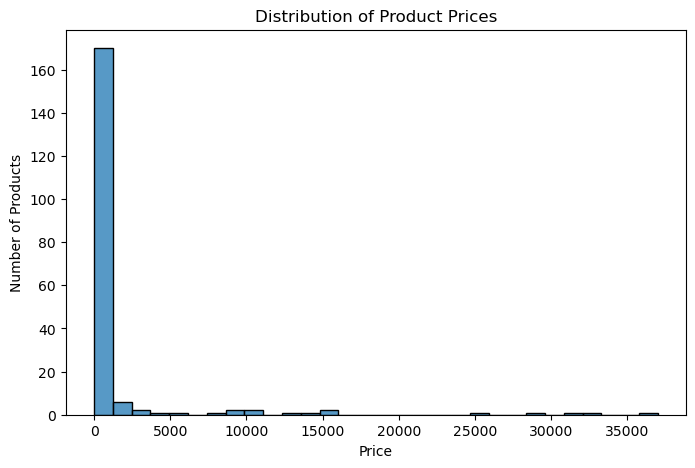

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

Most products are concentrated at lower price points, with a long right tail of very expensive items.
This means the dataset is right-skewed on price, which is common in e-commerce catalogs.

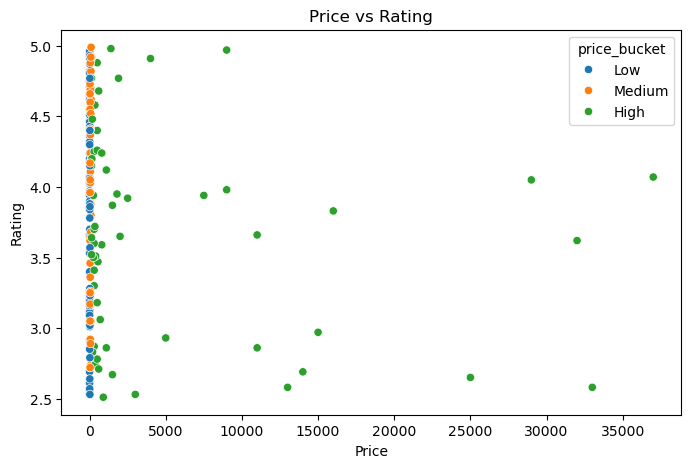

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="price", y="rating", hue="price_bucket")
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

Ratings do not appear to rise consistently with price.
Several lower- and medium-priced items receive ratings comparable to or better than expensive items.

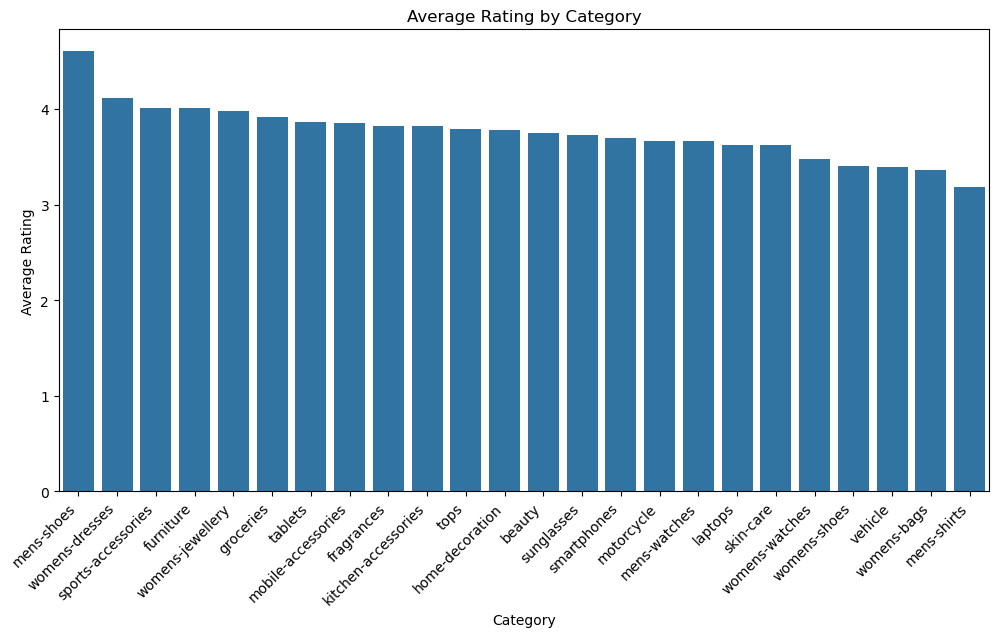

In [18]:
plt.figure(figsize=(12, 6))
category_rating = df.groupby("category")["rating"].mean().sort_values(ascending=False)

sns.barplot(x=category_rating.index, y=category_rating.values)
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.show()

In [19]:
df[[
"price",
"discountPercentage",
"rating",
"stock",
"weight",
"minimumOrderQuantity"
]].corr()

,price,discountPercentage,rating,stock,weight,minimumOrderQuantity
price,1.000000,-0.046356,-0.131419,0.055836,0.035043,-0.244714
discountPercentage,-0.046356,1.000000,-0.004919,0.019787,-0.080570,-0.000374
rating,-0.131419,-0.004919,1.000000,-0.047185,0.133863,0.003353
stock,0.055836,0.019787,-0.047185,1.000000,0.026470,0.139295
weight,0.035043,-0.080570,0.133863,0.026470,1.000000,-0.071300
minimumOrderQuantity,-0.244714,-0.000374,0.003353,0.139295,-0.071300,1.000000


Product categories differ meaningfully in average customer rating.
This suggests category-specific factors may influence satisfaction beyond price and discounts.

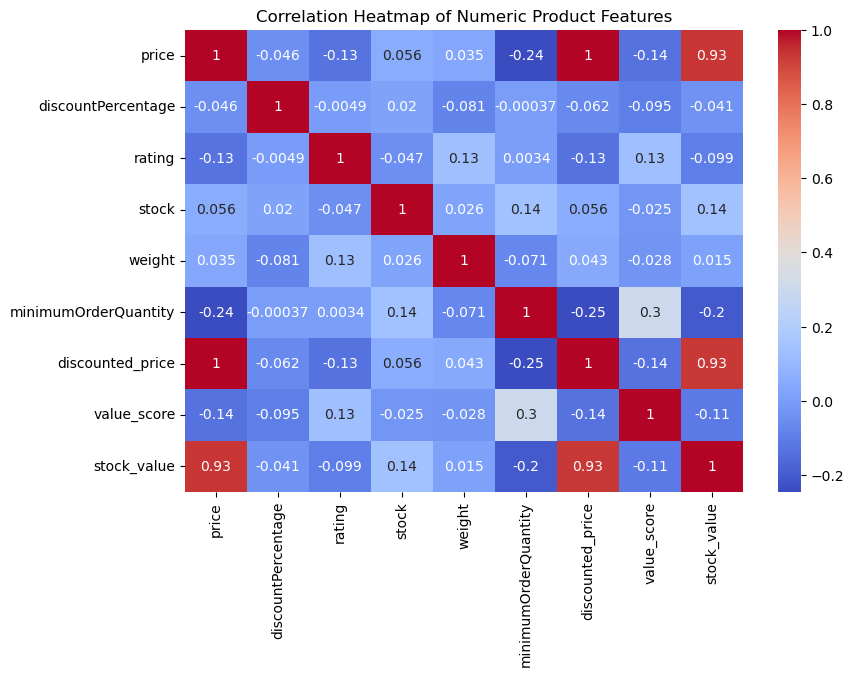

In [20]:
plt.figure(figsize=(9, 6))

corr_cols = [
    "price",
    "discountPercentage",
    "rating",
    "stock",
    "weight",
    "minimumOrderQuantity",
    "discounted_price",
    "value_score",
    "stock_value"
]

sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Product Features")
plt.show()

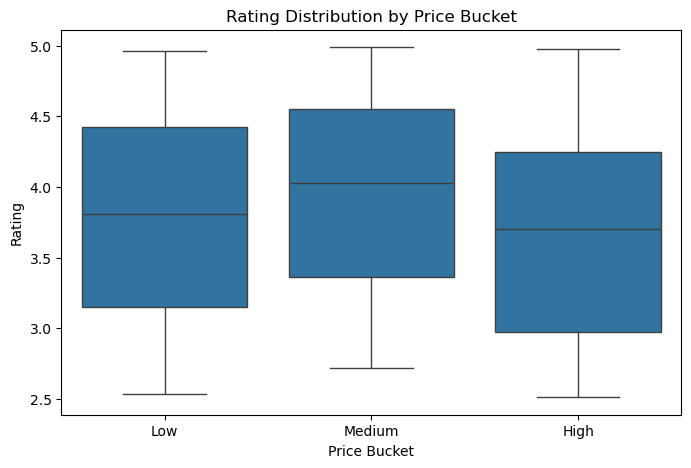

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="price_bucket", y="rating")
plt.title("Rating Distribution by Price Bucket")
plt.xlabel("Price Bucket")
plt.ylabel("Rating")
plt.show()

In [22]:
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
brand,92,47.42268
title,0,0.00000
id,0,0.00000
category,0,0.00000
price,0,0.00000
discountPercentage,0,0.00000
rating,0,0.00000
stock,0,0.00000
weight,0,0.00000
minimumOrderQuantity,0,0.00000


In [23]:
print("Unique categories:", df["category"].nunique())
print("Unique brands:", df["brand"].nunique())

Unique categories: 24
Unique brands: 63


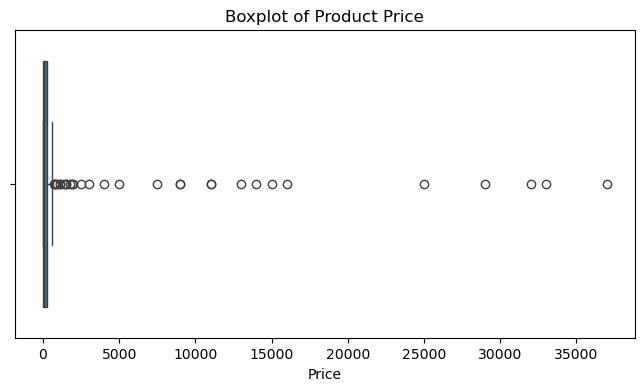

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Product Price")
plt.xlabel("Price")
plt.show()

Price has several extreme values, especially for luxury goods and vehicles.


In [25]:
import numpy as np

In [26]:
df["log_price"] = np.log1p(df["price"])
df["discount_amount"] = df["price"] - df["discounted_price"]
df["is_low_stock"] = (df["stock"] < 20).astype(int)

In [27]:
df[["price", "discounted_price", "discount_amount", "log_price", "is_low_stock"]].head()

,price,discounted_price,discount_amount,log_price,is_low_stock
0,9.99,8.943048,1.046952,2.396986,0
1,19.99,16.353819,3.636181,3.044046,0
2,14.99,13.514984,1.475016,2.771964,0
3,12.99,11.410416,1.579584,2.638343,0
4,8.99,7.961544,1.028456,2.301585,0


Midterm Conclusion
This analysis found that medium-priced products tend to have stronger average ratings than either very low-priced or very high-priced products. Category also appears to matter, as some categories consistently perform better on average customer ratings than others. High price alone does not appear to guarantee high satisfaction.
One limitation of this dataset is that it contains product-level information but not actual transaction behavior. 

Final Conclusion
This analysis explored how product characteristics relate to cart-level purchasing behavior.
Several patterns emerged:
• Medium-priced products tend to receive the highest average ratings.
• Higher-priced products contribute larger discounted totals within carts.
• Certain categories such as vehicles and watches produce significantly higher cart values compared with most retail categories.
• Cart quantity and price interactions strongly influence cart value in the regression model.
The results suggest that both product price and quantity behavior play important roles in determining the commercial value of items inside customer carts.